In [1]:
import pandas as pd
import numpy as np

In [2]:
df = pd.read_csv(r"C:\Users\User\Downloads\final_unified_traffic_dataset.xls",sep=',') #reading data

In [3]:
df.head()

,DateTime,Junction,Vehicles,ID,Year,Month,Day,Hour,DayOfWeek,DayName,IsWeekend,Date,Temperature,Humidity,WindSpeed,Precipitation,SportsEvent,Concert,PublicDemonstration,HasEvent
0,2015-11-01 00:00:00,1,15,20151101001,2015,11,1,0,6,Sunday,1,2015-11-01,0.497935,1.243730,0.401022,-0.524495,0,0,0,0
1,2015-11-01 01:00:00,1,13,20151101011,2015,11,1,1,6,Sunday,1,2015-11-01,-0.139092,0.067627,-0.296367,0.205979,0,0,0,0
2,2015-11-01 02:00:00,1,10,20151101021,2015,11,1,2,6,Sunday,1,2015-11-01,0.650660,-1.899525,2.399000,-0.355404,0,0,0,0
3,2015-11-01 03:00:00,1,7,20151101031,2015,11,1,3,6,Sunday,1,2015-11-01,1.530843,-1.815759,0.825867,-0.456858,0,0,0,0
4,2015-11-01 04:00:00,1,9,20151101041,2015,11,1,4,6,Sunday,1,2015-11-01,-0.235551,0.168957,-0.460694,0.118051,0,0,0,0


In [4]:
df.shape

(48120, 20)

In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 48120 entries, 0 to 48119
Data columns (total 20 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   DateTime             48120 non-null  object 
 1   Junction             48120 non-null  int64  
 2   Vehicles             48120 non-null  int64  
 3   ID                   48120 non-null  int64  
 4   Year                 48120 non-null  int64  
 5   Month                48120 non-null  int64  
 6   Day                  48120 non-null  int64  
 7   Hour                 48120 non-null  int64  
 8   DayOfWeek            48120 non-null  int64  
 9   DayName              48120 non-null  object 
 10  IsWeekend            48120 non-null  int64  
 11  Date                 48120 non-null  object 
 12  Temperature          48120 non-null  float64
 13  Humidity             48120 non-null  float64
 14  WindSpeed            48120 non-null  float64
 15  Precipitation        48120 non-null 

In [6]:
df.describe()

,Junction,Vehicles,ID,Year,Month,Day,Hour,DayOfWeek,IsWeekend,Temperature,Humidity,WindSpeed,Precipitation,SportsEvent,Concert,PublicDemonstration,HasEvent
count,48120.000000,48120.000000,4.812000e+04,48120.000000,48120.000000,48120.000000,48120.000000,48120.000000,48120.000000,4.812000e+04,4.812000e+04,4.812000e+04,4.812000e+04,48120.000000,48120.000000,48120.000000,48120.000000
mean,2.180549,22.791334,2.016330e+10,2016.269825,5.884289,15.700748,11.500000,2.996010,0.284289,-4.852127e-16,5.318734e-16,7.442093e-17,-6.917898e-17,0.061845,0.027930,0.013466,0.096259
std,0.966955,20.750063,5.944854e+06,0.616093,3.569872,8.784073,6.922258,2.000017,0.451080,1.000010e+00,1.000010e+00,1.000010e+00,1.000010e+00,0.240877,0.164775,0.115262,0.294950
min,1.000000,1.000000,2.015110e+10,2015.000000,1.000000,1.000000,0.000000,0.000000,0.000000,-3.941159e+00,-3.903156e+00,-2.410577e+00,-1.011477e+00,0.000000,0.000000,0.000000,0.000000
25%,1.000000,9.000000,2.016042e+10,2016.000000,3.000000,8.000000,5.750000,1.000000,0.000000,-6.676037e-01,-6.923477e-01,-6.911532e-01,-7.138767e-01,0.000000,0.000000,0.000000,0.000000
50%,2.000000,15.000000,2.016093e+10,2016.000000,5.000000,16.000000,11.500000,3.000000,0.000000,-4.335230e-04,7.504495e-03,-1.780520e-03,-3.012945e-01,0.000000,0.000000,0.000000,0.000000
75%,3.000000,29.000000,2.017023e+10,2017.000000,9.000000,23.000000,17.250000,5.000000,1.000000,6.667367e-01,6.884418e-01,6.855882e-01,4.088879e-01,0.000000,0.000000,0.000000,0.000000
max,4.000000,180.000000,2.017063e+10,2017.000000,12.000000,31.000000,23.000000,6.000000,1.000000,3.944311e+00,2.369168e+00,3.729649e+00,8.843150e+00,1.000000,1.000000,1.000000,1.000000


In [9]:
missing_data = pd.DataFrame({
    "Missing Values": df.isnull().sum(),
    "Missing Percentage": (
        df.isnull().sum() / len(df)
    ) * 100
})

missing_data
# there is no missing values

,Missing Values,Missing Percentage
DateTime,0,0.0
Junction,0,0.0
Vehicles,0,0.0
ID,0,0.0
Year,0,0.0
Month,0,0.0
Day,0,0.0
Hour,0,0.0
DayOfWeek,0,0.0
DayName,0,0.0


In [10]:
weather_columns = [
    "Temperature",
    "Humidity",
    "WindSpeed",
    "Precipitation"
]

In [11]:
df[weather_columns] = (
    df[weather_columns]
    .interpolate(method="linear")
)

In [12]:
df[weather_columns].isnull().sum()

Temperature      0
Humidity         0
WindSpeed        0
Precipitation    0
dtype: int64

In [14]:
df.duplicated().sum()

0

In [16]:
df["ID"].duplicated().sum()

0

In [17]:
df["DateTime"] = pd.to_datetime(
    df["DateTime"]
)

In [18]:
df["Date"] = pd.to_datetime(
    df["Date"]
)

In [19]:
int_columns = [
    "Junction",
    "Vehicles",
    "Year",
    "Month",
    "Day",
    "Hour",
    "DayOfWeek",
    "IsWeekend",
    "SportsEvent",
    "Concert",
    "PublicDemonstration",
    "HasEvent"
] # defining integer columns

In [20]:
df[int_columns] = df[int_columns].astype(int)

In [21]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 48120 entries, 0 to 48119
Data columns (total 20 columns):
 #   Column               Non-Null Count  Dtype         
---  ------               --------------  -----         
 0   DateTime             48120 non-null  datetime64[ns]
 1   Junction             48120 non-null  int32         
 2   Vehicles             48120 non-null  int32         
 3   ID                   48120 non-null  int64         
 4   Year                 48120 non-null  int32         
 5   Month                48120 non-null  int32         
 6   Day                  48120 non-null  int32         
 7   Hour                 48120 non-null  int32         
 8   DayOfWeek            48120 non-null  int32         
 9   DayName              48120 non-null  object        
 10  IsWeekend            48120 non-null  int32         
 11  Date                 48120 non-null  datetime64[ns]
 12  Temperature          48120 non-null  float64       
 13  Humidity             48120 non-

In [22]:
hourly_traffic = (
    df.groupby(
        [
            pd.Grouper(
                key="DateTime",
                freq="h"
            ),
            "Junction"
        ]
    )
    .agg({
        "Vehicles": "sum",
        "Temperature": "mean",
        "Humidity": "mean",
        "WindSpeed": "mean",
        "Precipitation": "sum",
        "SportsEvent": "max",
        "Concert": "max",
        "PublicDemonstration": "max",
        "HasEvent": "max"
    })
    .reset_index()
)

In [23]:
hourly_traffic.head()

,DateTime,Junction,Vehicles,Temperature,Humidity,WindSpeed,Precipitation,SportsEvent,Concert,PublicDemonstration,HasEvent
0,2015-11-01 00:00:00,1,15,0.497935,1.243730,0.401022,-0.524495,0,0,0,0
1,2015-11-01 00:00:00,2,6,0.497935,1.243730,0.401022,-0.524495,0,0,0,0
2,2015-11-01 00:00:00,3,9,0.497935,1.243730,0.401022,-0.524495,0,0,0,0
3,2015-11-01 01:00:00,1,13,-0.139092,0.067627,-0.296367,0.205979,0,0,0,0
4,2015-11-01 01:00:00,2,6,-0.139092,0.067627,-0.296367,0.205979,0,0,0,0


In [24]:
hourly_traffic.duplicated(
    subset=["DateTime", "Junction"]
).sum()

0

In [25]:
hourly_traffic["Year"] = (
    hourly_traffic["DateTime"].dt.year
)

hourly_traffic["Month"] = (
    hourly_traffic["DateTime"].dt.month
)

hourly_traffic["Day"] = (
    hourly_traffic["DateTime"].dt.day
)

hourly_traffic["Hour"] = (
    hourly_traffic["DateTime"].dt.hour
)

hourly_traffic["DayOfWeek"] = (
    hourly_traffic["DateTime"].dt.dayofweek
)

In [26]:
hourly_traffic["IsWeekend"] = np.where(
    hourly_traffic["DayOfWeek"] >= 5,
    1,
    0
)

In [27]:
hourly_traffic.head()

,DateTime,Junction,Vehicles,Temperature,Humidity,WindSpeed,Precipitation,SportsEvent,Concert,PublicDemonstration,HasEvent,Year,Month,Day,Hour,DayOfWeek,IsWeekend
0,2015-11-01 00:00:00,1,15,0.497935,1.243730,0.401022,-0.524495,0,0,0,0,2015,11,1,0,6,1
1,2015-11-01 00:00:00,2,6,0.497935,1.243730,0.401022,-0.524495,0,0,0,0,2015,11,1,0,6,1
2,2015-11-01 00:00:00,3,9,0.497935,1.243730,0.401022,-0.524495,0,0,0,0,2015,11,1,0,6,1
3,2015-11-01 01:00:00,1,13,-0.139092,0.067627,-0.296367,0.205979,0,0,0,0,2015,11,1,1,6,1
4,2015-11-01 01:00:00,2,6,-0.139092,0.067627,-0.296367,0.205979,0,0,0,0,2015,11,1,1,6,1


In [28]:
from sklearn.preprocessing import StandardScaler

In [30]:
scale_columns = [
    "Temperature",
    "Humidity",
    "WindSpeed",
    "Precipitation"
]

In [31]:
scaler = StandardScaler()

In [32]:
scaled_data = scaler.fit_transform(
    hourly_traffic[scale_columns]
)


In [33]:
scaled_columns = [
    "Temperature_scaled",
    "Humidity_scaled",
    "WindSpeed_scaled",
    "Precipitation_scaled"
]

In [34]:
hourly_traffic[scaled_columns] = scaled_data

In [35]:
hourly_traffic[
    scale_columns + scaled_columns
].head()

,Temperature,Humidity,WindSpeed,Precipitation,Temperature_scaled,Humidity_scaled,WindSpeed_scaled,Precipitation_scaled
0,0.497935,1.243730,0.401022,-0.524495,0.497935,1.243730,0.401022,-0.524495
1,0.497935,1.243730,0.401022,-0.524495,0.497935,1.243730,0.401022,-0.524495
2,0.497935,1.243730,0.401022,-0.524495,0.497935,1.243730,0.401022,-0.524495
3,-0.139092,0.067627,-0.296367,0.205979,-0.139092,0.067627,-0.296367,0.205979
4,-0.139092,0.067627,-0.296367,0.205979,-0.139092,0.067627,-0.296367,0.205979


In [36]:
print(
    "Missing Values:",
    hourly_traffic.isnull().sum().sum()
)

print(
    "Duplicate Rows:",
    hourly_traffic.duplicated().sum()
)

print(
    "Dataset Shape:",
    hourly_traffic.shape
)

Missing Values: 0
Duplicate Rows: 0
Dataset Shape: (48120, 21)


In [38]:
hourly_traffic.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 48120 entries, 0 to 48119
Data columns (total 21 columns):
 #   Column                Non-Null Count  Dtype         
---  ------                --------------  -----         
 0   DateTime              48120 non-null  datetime64[ns]
 1   Junction              48120 non-null  int32         
 2   Vehicles              48120 non-null  int32         
 3   Temperature           48120 non-null  float64       
 4   Humidity              48120 non-null  float64       
 5   WindSpeed             48120 non-null  float64       
 6   Precipitation         48120 non-null  float64       
 7   SportsEvent           48120 non-null  int32         
 8   Concert               48120 non-null  int32         
 9   PublicDemonstration   48120 non-null  int32         
 10  HasEvent              48120 non-null  int32         
 11  Year                  48120 non-null  int32         
 12  Month                 48120 non-null  int32         
 13  Day             

In [39]:
# hourly_traffic.to_csv(
#     "preprocessed_unified_traffic_dataset.csv",
#     index=False
# )

In [42]:
import matplotlib.pyplot as plt
import seaborn as sns

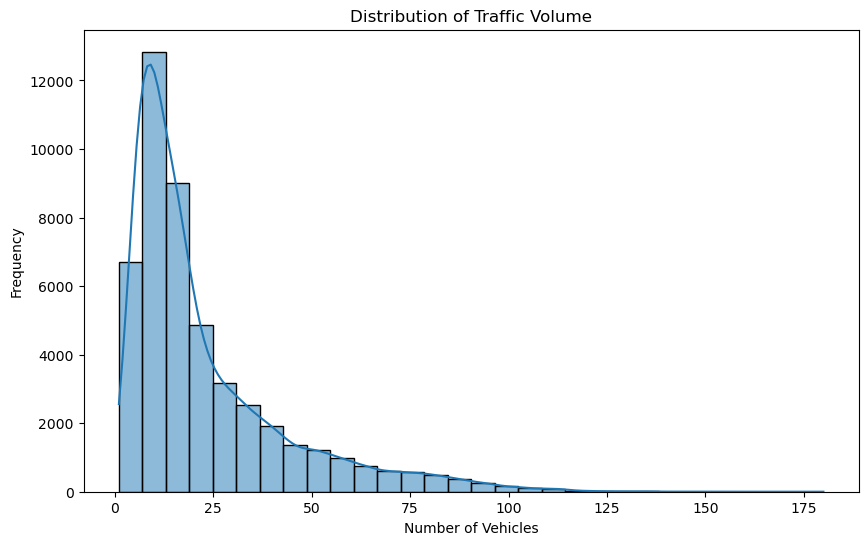

In [43]:
plt.figure(figsize=(10, 6))

sns.histplot(
    data=hourly_traffic,
    x="Vehicles",
    bins=30,
    kde=True
)

plt.title("Distribution of Traffic Volume")
plt.xlabel("Number of Vehicles")
plt.ylabel("Frequency")

plt.show()

In [44]:
hourly_avg = (
    hourly_traffic
    .groupby("Hour")["Vehicles"]
    .mean()
    .reset_index()
)

hourly_avg

,Hour,Vehicles
0,0,23.540648
1,1,19.654863
2,2,17.102743
3,3,14.847382
4,4,12.973067
5,5,12.173566
6,6,12.980050
7,7,14.703242
8,8,16.402993
9,9,19.379551


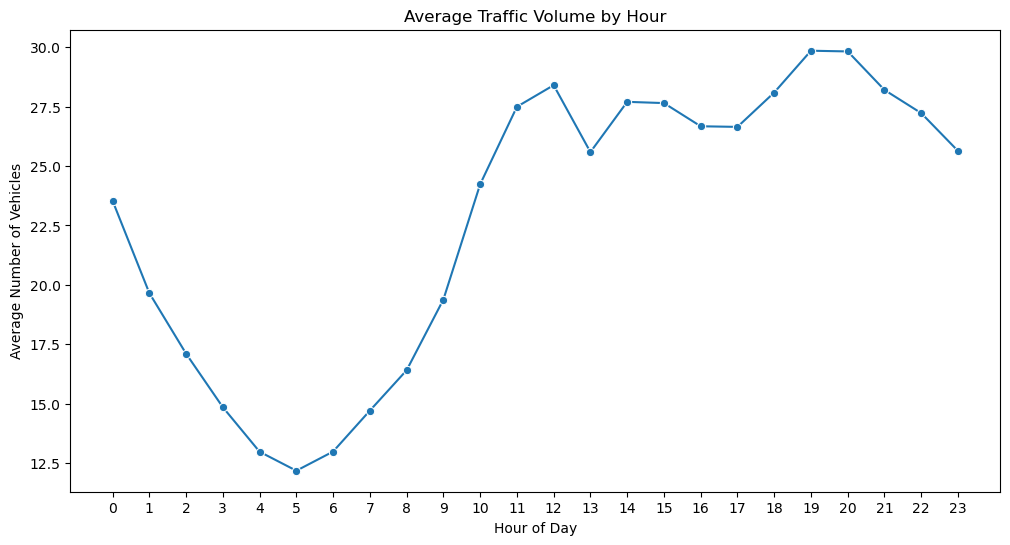

In [45]:
plt.figure(figsize=(12, 6))

sns.lineplot(
    data=hourly_avg,
    x="Hour",
    y="Vehicles",
    marker="o"
)

plt.title("Average Traffic Volume by Hour")
plt.xlabel("Hour of Day")
plt.ylabel("Average Number of Vehicles")

plt.xticks(range(0, 24))

plt.show()

In [46]:
junction_avg = (
    hourly_traffic
    .groupby("Junction")["Vehicles"]
    .mean()
    .reset_index()
)

junction_avg

,Junction,Vehicles
0,1,45.052906
1,2,14.253221
2,3,13.694010
3,4,7.251611


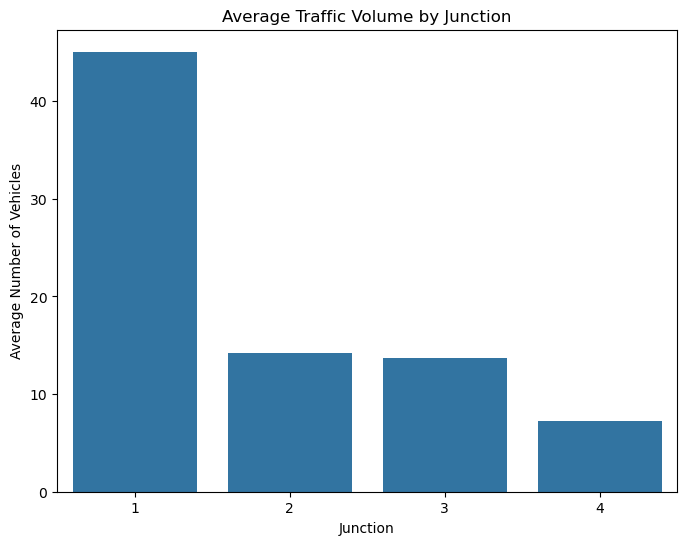

In [47]:
plt.figure(figsize=(8, 6))

sns.barplot(
    data=junction_avg,
    x="Junction",
    y="Vehicles"
)

plt.title("Average Traffic Volume by Junction")
plt.xlabel("Junction")
plt.ylabel("Average Number of Vehicles")

plt.show()

In [48]:
weekend_avg = (
    hourly_traffic
    .groupby("IsWeekend")["Vehicles"]
    .mean()
    .reset_index()
)

weekend_avg

,IsWeekend,Vehicles
0,0,24.760163
1,1,17.834722


In [49]:
weekend_avg["DayType"] = weekend_avg[
    "IsWeekend"
].map({
    0: "Weekday",
    1: "Weekend"
})

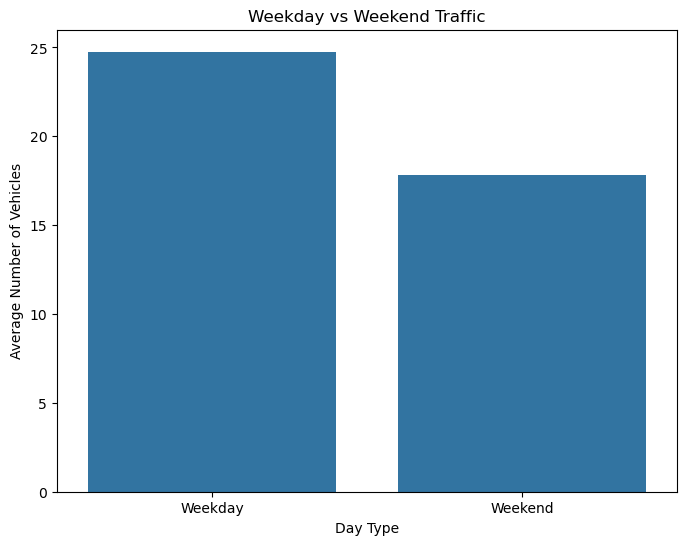

In [50]:
plt.figure(figsize=(8, 6))

sns.barplot(
    data=weekend_avg,
    x="DayType",
    y="Vehicles"
)

plt.title("Weekday vs Weekend Traffic")
plt.xlabel("Day Type")
plt.ylabel("Average Number of Vehicles")

plt.show()

In [51]:
day_mapping = {
    0: "Monday",
    1: "Tuesday",
    2: "Wednesday",
    3: "Thursday",
    4: "Friday",
    5: "Saturday",
    6: "Sunday"
}

In [52]:
hourly_traffic["DayName"] = (
    hourly_traffic["DayOfWeek"]
    .map(day_mapping)
)

In [53]:
day_avg = (
    hourly_traffic
    .groupby(
        ["DayOfWeek", "DayName"]
    )["Vehicles"]
    .mean()
    .reset_index()
)

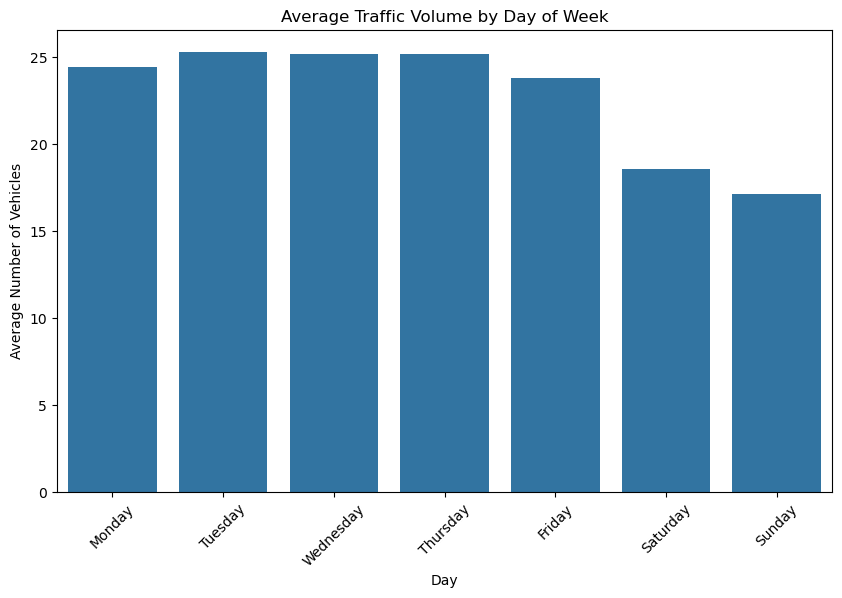

In [54]:
plt.figure(figsize=(10, 6))

sns.barplot(
    data=day_avg,
    x="DayName",
    y="Vehicles"
)

plt.title("Average Traffic Volume by Day of Week")
plt.xlabel("Day")
plt.ylabel("Average Number of Vehicles")

plt.xticks(rotation=45)

plt.show()

In [55]:
hourly_traffic["YearMonth"] = (
    hourly_traffic["DateTime"]
    .dt.to_period("M")
)

In [56]:
monthly_traffic = (
    hourly_traffic
    .groupby("YearMonth")["Vehicles"]
    .mean()
    .reset_index()
)

In [58]:
monthly_traffic["YearMonth"] = (
    monthly_traffic["YearMonth"]
    .astype(str)
)

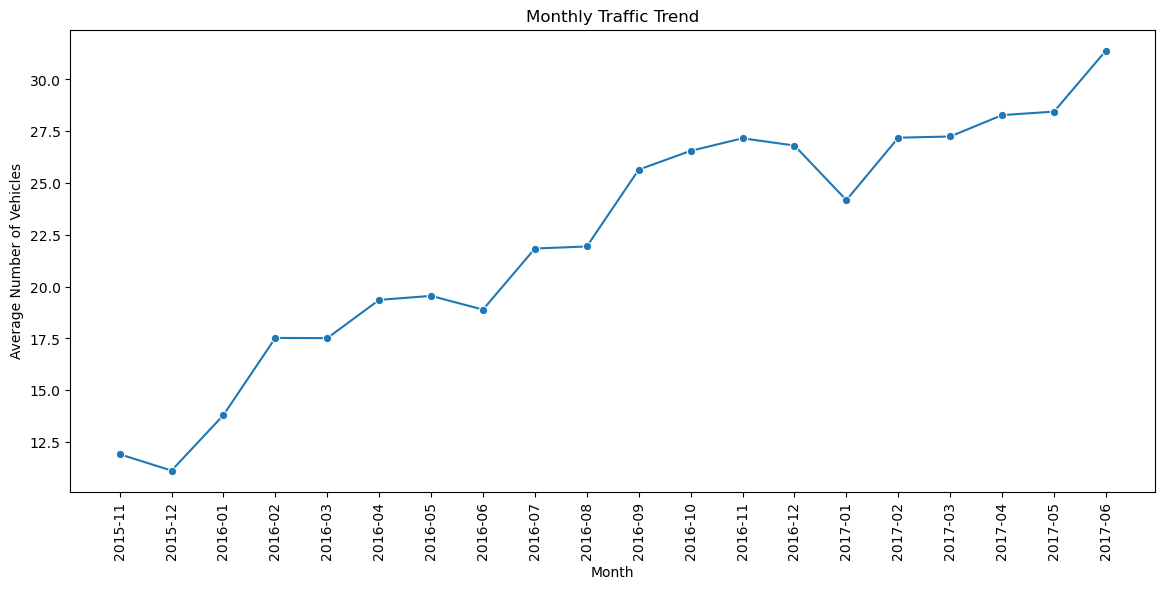

In [59]:
plt.figure(figsize=(14, 6))

sns.lineplot(
    data=monthly_traffic,
    x="YearMonth",
    y="Vehicles",
    marker="o"
)

plt.title("Monthly Traffic Trend")
plt.xlabel("Month")
plt.ylabel("Average Number of Vehicles")

plt.xticks(
    rotation=90
)

plt.show()

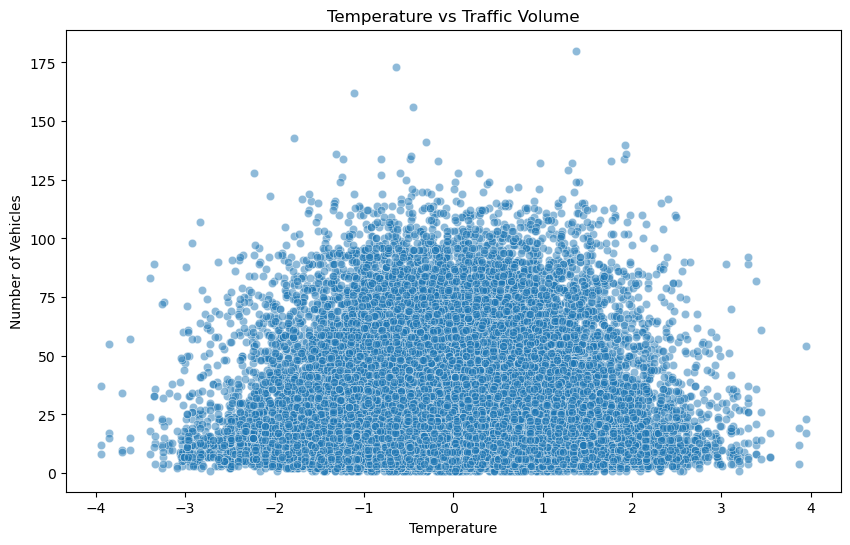

In [60]:
plt.figure(figsize=(10, 6))

sns.scatterplot(
    data=hourly_traffic,
    x="Temperature",
    y="Vehicles",
    alpha=0.5
)

plt.title("Temperature vs Traffic Volume")
plt.xlabel("Temperature")
plt.ylabel("Number of Vehicles")

plt.show()

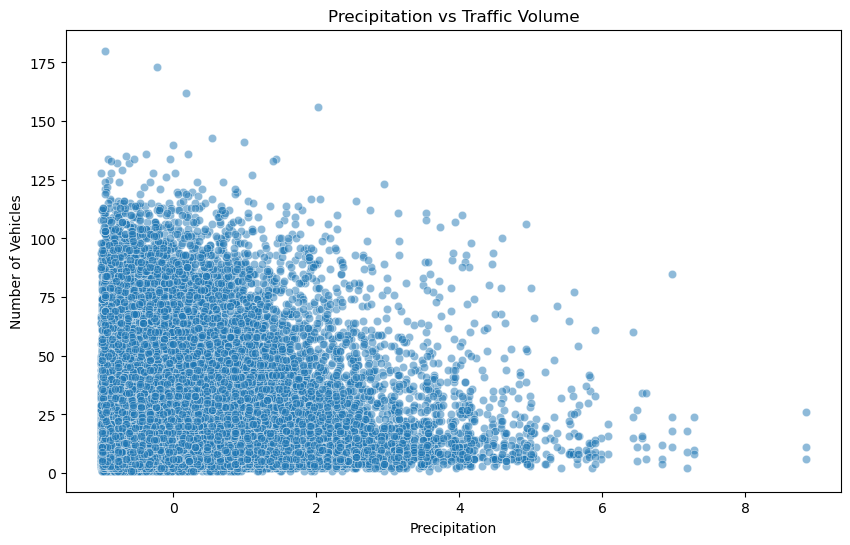

In [61]:
plt.figure(figsize=(10, 6))

sns.scatterplot(
    data=hourly_traffic,
    x="Precipitation",
    y="Vehicles",
    alpha=0.5
)

plt.title("Precipitation vs Traffic Volume")
plt.xlabel("Precipitation")
plt.ylabel("Number of Vehicles")

plt.show()

In [62]:
event_traffic = (
    hourly_traffic
    .groupby("HasEvent")["Vehicles"]
    .mean()
    .reset_index()
)

In [63]:
event_traffic["EventType"] = (
    event_traffic["HasEvent"]
    .map({
        0: "No Event",
        1: "Event"
    })
)

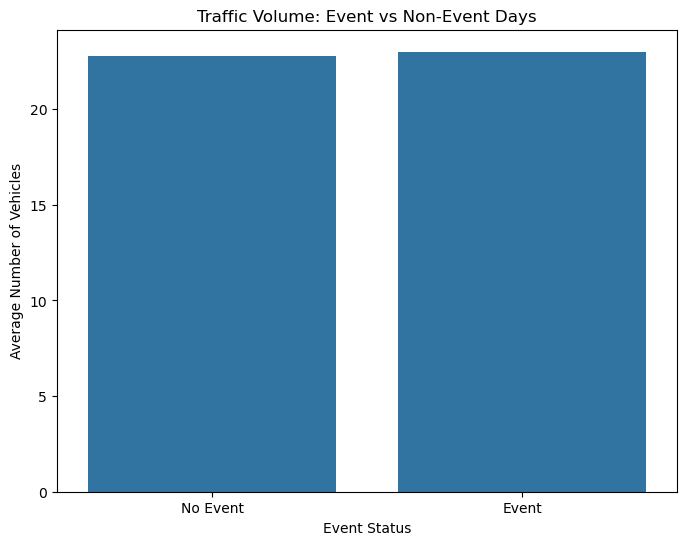

In [64]:
plt.figure(figsize=(8, 6))

sns.barplot(
    data=event_traffic,
    x="EventType",
    y="Vehicles"
)

plt.title("Traffic Volume: Event vs Non-Event Days")
plt.xlabel("Event Status")
plt.ylabel("Average Number of Vehicles")

plt.show()

In [65]:
correlation_columns = [
    "Vehicles",
    "Temperature",
    "Humidity",
    "WindSpeed",
    "Precipitation",
    "Hour",
    "DayOfWeek",
    "IsWeekend",
    "SportsEvent",
    "Concert",
    "PublicDemonstration",
    "HasEvent"
]

In [67]:
correlation_matrix = (
    hourly_traffic[
        correlation_columns
    ]
    .corr()
)

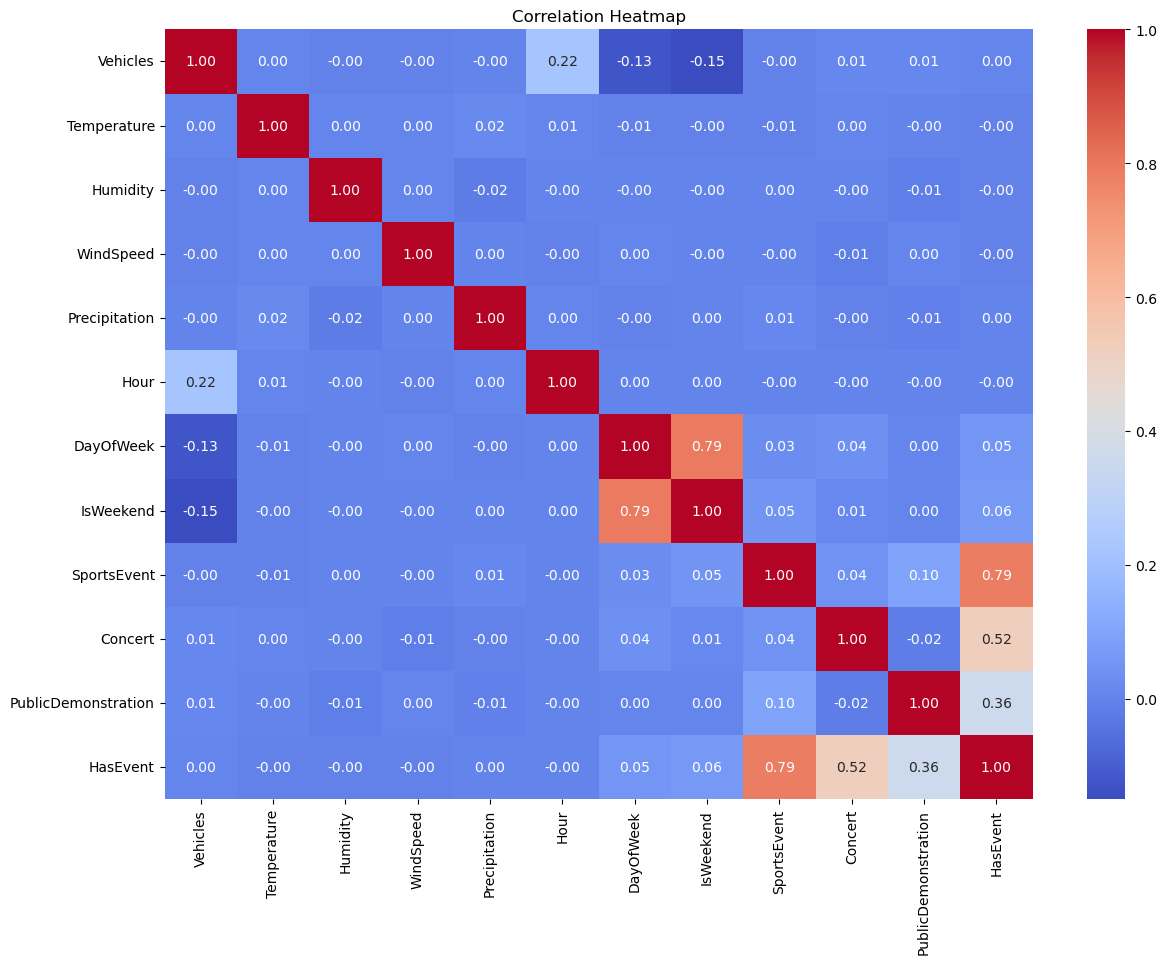

In [68]:
plt.figure(figsize=(14, 10))

sns.heatmap(
    correlation_matrix,
    annot=True,
    fmt=".2f",
    cmap="coolwarm"
)

plt.title("Correlation Heatmap")

plt.show()

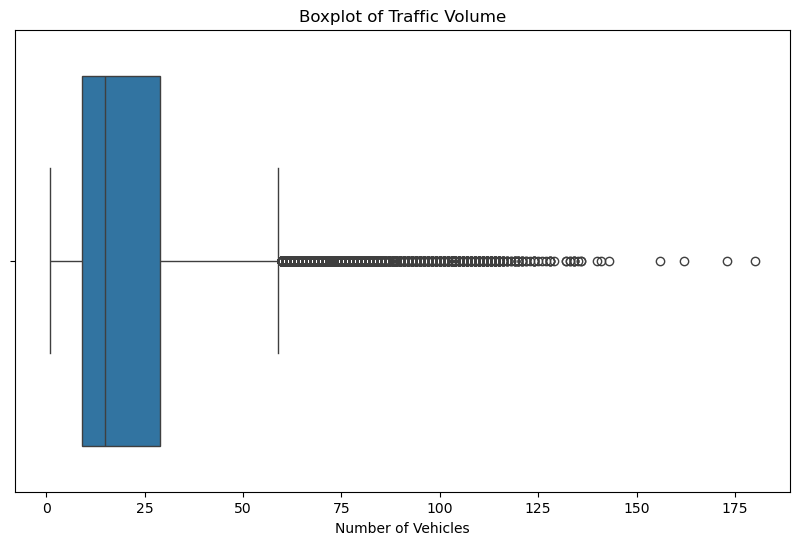

In [69]:
plt.figure(figsize=(10, 6))

sns.boxplot(
    data=hourly_traffic,
    x="Vehicles"
)

plt.title("Boxplot of Traffic Volume")
plt.xlabel("Number of Vehicles")

plt.show()

In [70]:
Q1 = hourly_traffic["Vehicles"].quantile(0.25)
Q3 = hourly_traffic["Vehicles"].quantile(0.75)

IQR = Q3 - Q1

lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

print("Lower Bound:", lower_bound)
print("Upper Bound:", upper_bound)

Lower Bound: -21.0
Upper Bound: 59.0


In [71]:
traffic_outliers = hourly_traffic[
    (
        hourly_traffic["Vehicles"] < lower_bound
    )
    |
    (
        hourly_traffic["Vehicles"] > upper_bound
    )
]

traffic_outliers.head()

,DateTime,Junction,Vehicles,Temperature,Humidity,WindSpeed,Precipitation,SportsEvent,Concert,PublicDemonstration,...,Day,Hour,DayOfWeek,IsWeekend,Temperature_scaled,Humidity_scaled,WindSpeed_scaled,Precipitation_scaled,DayName,YearMonth
7043,2016-02-06 19:00:00,3,71,-0.866549,-0.324858,-0.532838,-0.740931,0,1,0,...,6,19,5,1,-0.866549,-0.324858,-0.532838,-0.740931,Saturday,2016-02
7809,2016-02-17 11:00:00,1,70,-1.196115,0.042632,0.934083,-0.382458,0,0,0,...,17,11,2,0,-1.196115,0.042632,0.934083,-0.382458,Wednesday,2016-02
8670,2016-02-29 10:00:00,1,64,0.142244,0.160850,-0.510794,2.437981,0,0,0,...,29,10,0,0,0.142244,0.160850,-0.510794,2.437981,Monday,2016-02
8673,2016-02-29 11:00:00,1,62,-2.140603,-0.524140,-1.035840,-0.598895,0,0,0,...,29,11,0,0,-2.140603,-0.524140,-1.035840,-0.598895,Monday,2016-02
8906,2016-03-03 16:00:00,3,68,-1.829123,1.682826,0.437093,-0.450095,0,0,0,...,3,16,3,0,-1.829123,1.682826,0.437093,-0.450095,Thursday,2016-03


#### Feature Engineering and Selection

In [73]:
df1 = pd.read_csv(
    r"C:\Users\User\Downloads\preprocessed_unified_traffic_dataset.xls",sep=','
)

df1.head()

,DateTime,Junction,Vehicles,Temperature,Humidity,WindSpeed,Precipitation,SportsEvent,Concert,PublicDemonstration,...,Year,Month,Day,Hour,DayOfWeek,IsWeekend,Temperature_scaled,Humidity_scaled,WindSpeed_scaled,Precipitation_scaled
0,2015-11-01 00:00:00,1,15,0.497935,1.243730,0.401022,-0.524495,0,0,0,...,2015,11,1,0,6,1,0.497935,1.243730,0.401022,-0.524495
1,2015-11-01 00:00:00,2,6,0.497935,1.243730,0.401022,-0.524495,0,0,0,...,2015,11,1,0,6,1,0.497935,1.243730,0.401022,-0.524495
2,2015-11-01 00:00:00,3,9,0.497935,1.243730,0.401022,-0.524495,0,0,0,...,2015,11,1,0,6,1,0.497935,1.243730,0.401022,-0.524495
3,2015-11-01 01:00:00,1,13,-0.139092,0.067627,-0.296367,0.205979,0,0,0,...,2015,11,1,1,6,1,-0.139092,0.067627,-0.296367,0.205979
4,2015-11-01 01:00:00,2,6,-0.139092,0.067627,-0.296367,0.205979,0,0,0,...,2015,11,1,1,6,1,-0.139092,0.067627,-0.296367,0.205979


In [75]:
df1.shape

(48120, 21)

In [76]:
df1.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 48120 entries, 0 to 48119
Data columns (total 21 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   DateTime              48120 non-null  object 
 1   Junction              48120 non-null  int64  
 2   Vehicles              48120 non-null  int64  
 3   Temperature           48120 non-null  float64
 4   Humidity              48120 non-null  float64
 5   WindSpeed             48120 non-null  float64
 6   Precipitation         48120 non-null  float64
 7   SportsEvent           48120 non-null  int64  
 8   Concert               48120 non-null  int64  
 9   PublicDemonstration   48120 non-null  int64  
 10  HasEvent              48120 non-null  int64  
 11  Year                  48120 non-null  int64  
 12  Month                 48120 non-null  int64  
 13  Day                   48120 non-null  int64  
 14  Hour                  48120 non-null  int64  
 15  DayOfWeek          

In [101]:
df1["DateTime"] = pd.to_datetime(
    df1["DateTime"]
)

In [102]:
df1 = df1.sort_values(
    by=["Junction", "DateTime"]
).reset_index(drop=True)

In [103]:
df1[
    [
        "DateTime",
        "Hour",
        "DayOfWeek",
        "Month"
    ]
].head()

,DateTime,Hour,DayOfWeek,Month
0,2015-11-01 00:00:00,0,6,11
1,2015-11-01 01:00:00,1,6,11
2,2015-11-01 02:00:00,2,6,11
3,2015-11-01 03:00:00,3,6,11
4,2015-11-01 04:00:00,4,6,11


In [104]:
df1["Hour"] = df1["DateTime"].dt.hour

df1["DayOfWeek"] = (
    df1["DateTime"].dt.dayofweek
)

df1["Month"] = df1["DateTime"].dt.month

In [105]:
df1["Vehicles_lag_1"] = (
    df1.groupby("Junction")["Vehicles"]
    .shift(1)
)

In [106]:
df1[
    [
        "DateTime",
        "Junction",
        "Vehicles",
        "Vehicles_lag_1"
    ]
].head(10)

,DateTime,Junction,Vehicles,Vehicles_lag_1
0,2015-11-01 00:00:00,1,15,NaN
1,2015-11-01 01:00:00,1,13,15.0
2,2015-11-01 02:00:00,1,10,13.0
3,2015-11-01 03:00:00,1,7,10.0
4,2015-11-01 04:00:00,1,9,7.0
5,2015-11-01 05:00:00,1,6,9.0
6,2015-11-01 06:00:00,1,9,6.0
7,2015-11-01 07:00:00,1,8,9.0
8,2015-11-01 08:00:00,1,11,8.0
9,2015-11-01 09:00:00,1,12,11.0


In [107]:
df1["Vehicles_lag_2"] = (
    df1.groupby("Junction")["Vehicles"]
    .shift(2)
)

In [108]:
df1[
    [
        "DateTime",
        "Junction",
        "Vehicles",
        "Vehicles_lag_1",
        "Vehicles_lag_2"
    ]
].head(10)

,DateTime,Junction,Vehicles,Vehicles_lag_1,Vehicles_lag_2
0,2015-11-01 00:00:00,1,15,NaN,NaN
1,2015-11-01 01:00:00,1,13,15.0,NaN
2,2015-11-01 02:00:00,1,10,13.0,15.0
3,2015-11-01 03:00:00,1,7,10.0,13.0
4,2015-11-01 04:00:00,1,9,7.0,10.0
5,2015-11-01 05:00:00,1,6,9.0,7.0
6,2015-11-01 06:00:00,1,9,6.0,9.0
7,2015-11-01 07:00:00,1,8,9.0,6.0
8,2015-11-01 08:00:00,1,11,8.0,9.0
9,2015-11-01 09:00:00,1,12,11.0,8.0


In [109]:
df1["Vehicles_lag_3"] = (
    df1.groupby("Junction")["Vehicles"]
    .shift(3)
)

In [111]:
df1["Vehicles_lag_24"] = (
    df1.groupby("Junction")["Vehicles"]
    .shift(24)
)

In [112]:
df1[
    [
        "DateTime",
        "Junction",
        "Vehicles",
        "Vehicles_lag_24"
    ]
].head(30)

,DateTime,Junction,Vehicles,Vehicles_lag_24
0,2015-11-01 00:00:00,1,15,NaN
1,2015-11-01 01:00:00,1,13,NaN
2,2015-11-01 02:00:00,1,10,NaN
3,2015-11-01 03:00:00,1,7,NaN
4,2015-11-01 04:00:00,1,9,NaN
5,2015-11-01 05:00:00,1,6,NaN
6,2015-11-01 06:00:00,1,9,NaN
7,2015-11-01 07:00:00,1,8,NaN
8,2015-11-01 08:00:00,1,11,NaN
9,2015-11-01 09:00:00,1,12,NaN


In [113]:
df1["Vehicles_lag_168"] = (
    df1.groupby("Junction")["Vehicles"]
    .shift(168)
)

In [114]:
df1["Vehicles_rolling_3"] = (
    df1.groupby("Junction")["Vehicles"]
    .transform(
        lambda x: x.shift(1)
        .rolling(window=3)
        .mean()
    )
)

In [115]:
df1["Vehicles_rolling_24"] = (
    df1.groupby("Junction")["Vehicles"]
    .transform(
        lambda x: x.shift(1)
        .rolling(window=24)
        .mean()
    )
)

In [116]:
df1[
    [
        "DateTime",
        "DayOfWeek",
        "IsWeekend"
    ]
].head()

,DateTime,DayOfWeek,IsWeekend
0,2015-11-01 00:00:00,6,1
1,2015-11-01 01:00:00,6,1
2,2015-11-01 02:00:00,6,1
3,2015-11-01 03:00:00,6,1
4,2015-11-01 04:00:00,6,1


In [117]:
df1[
    [
        "SportsEvent",
        "Concert",
        "PublicDemonstration",
        "HasEvent"
    ]
].head(20)

,SportsEvent,Concert,PublicDemonstration,HasEvent
0,0,0,0,0
1,0,0,0,0
2,0,0,0,0
3,0,0,0,0
4,0,0,0,0
5,0,0,0,0
6,0,0,0,0
7,0,0,0,0
8,0,0,0,0
9,0,0,0,0


In [118]:
df1["HasEvent"] = np.where(
    (
        (df1["SportsEvent"] == 1) |
        (df1["Concert"] == 1) |
        (
            df1["PublicDemonstration"] == 1
        )
    ),
    1,
    0
)

In [119]:
df1["IsRushHour"] = np.where(
    (
        df1["Hour"].between(7, 10)
    )
    |
    (
        df1["Hour"].between(16, 19)
    ),
    1,
    0
)

In [120]:
df1["IsRushHour"] = np.where(
    (
        df1["Hour"].between(7, 10)
    )
    |
    (
        df1["Hour"].between(16, 19)
    ),
    1,
    0
)

In [121]:
df1[
    [
        "Vehicles_lag_1",
        "Vehicles_lag_2",
        "Vehicles_lag_3",
        "Vehicles_lag_24",
        "Vehicles_lag_168",
        "Vehicles_rolling_3",
        "Vehicles_rolling_24"
    ]
].isnull().sum()

Vehicles_lag_1           4
Vehicles_lag_2           8
Vehicles_lag_3          12
Vehicles_lag_24         96
Vehicles_lag_168       672
Vehicles_rolling_3      12
Vehicles_rolling_24     96
dtype: int64

In [122]:
df1.dropna(
    subset=[
        "Vehicles_lag_1",
        "Vehicles_lag_2",
        "Vehicles_lag_3",
        "Vehicles_lag_24",
        "Vehicles_lag_168",
        "Vehicles_rolling_3",
        "Vehicles_rolling_24"
    ],
    inplace=True
)

In [123]:
df1.reset_index(
    drop=True,
    inplace=True
)

In [124]:
feature_columns = [
    "Junction",
    "Hour",
    "DayOfWeek",
    "Month",
    "IsWeekend",
    "IsRushHour",
    "Temperature_scaled",
    "Humidity_scaled",
    "WindSpeed_scaled",
    "Precipitation_scaled",
    "SportsEvent",
    "Concert",
    "PublicDemonstration",
    "HasEvent",
    "Vehicles_lag_1",
    "Vehicles_lag_2",
    "Vehicles_lag_3",
    "Vehicles_lag_24",
    "Vehicles_lag_168",
    "Vehicles_rolling_3",
    "Vehicles_rolling_24",
    "Vehicles"
]

In [125]:
correlation_matrix = df1[
    feature_columns
].corr()

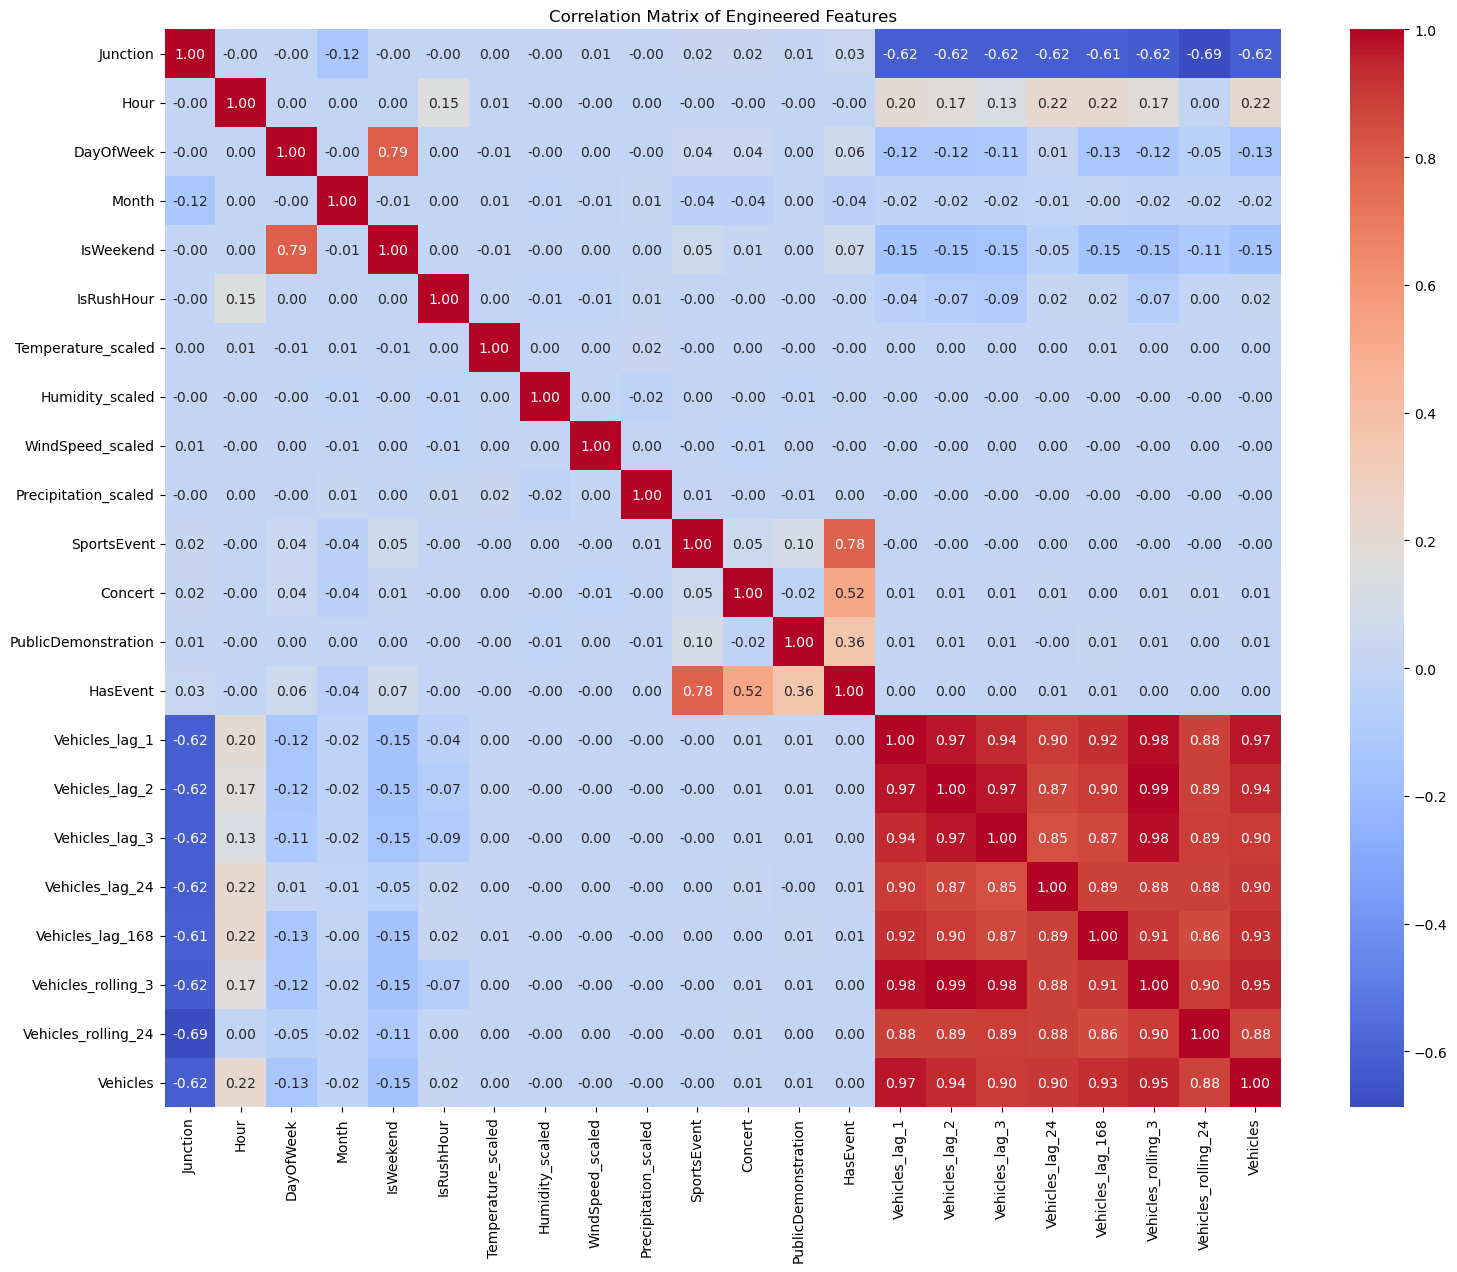

In [126]:
plt.figure(figsize=(18, 14))

sns.heatmap(
    correlation_matrix,
    annot=True,
    fmt=".2f",
    cmap="coolwarm"
)

plt.title(
    "Correlation Matrix of Engineered Features"
)

plt.show()

In [127]:
vehicle_correlation = (
    correlation_matrix["Vehicles"]
    .drop("Vehicles")
    .abs()
    .sort_values(
        ascending=False
    )
)

In [128]:
vehicle_correlation

Vehicles_lag_1          0.970072
Vehicles_rolling_3      0.948963
Vehicles_lag_2          0.936904
Vehicles_lag_168        0.933112
Vehicles_lag_24         0.904835
Vehicles_lag_3          0.900746
Vehicles_rolling_24     0.879694
Junction                0.616180
Hour                    0.221029
IsWeekend               0.151111
DayOfWeek               0.126301
Month                   0.017558
IsRushHour              0.015688
Concert                 0.009737
PublicDemonstration     0.007939
Temperature_scaled      0.004325
Humidity_scaled         0.003795
HasEvent                0.002921
WindSpeed_scaled        0.002805
SportsEvent             0.002523
Precipitation_scaled    0.002339
Name: Vehicles, dtype: float64

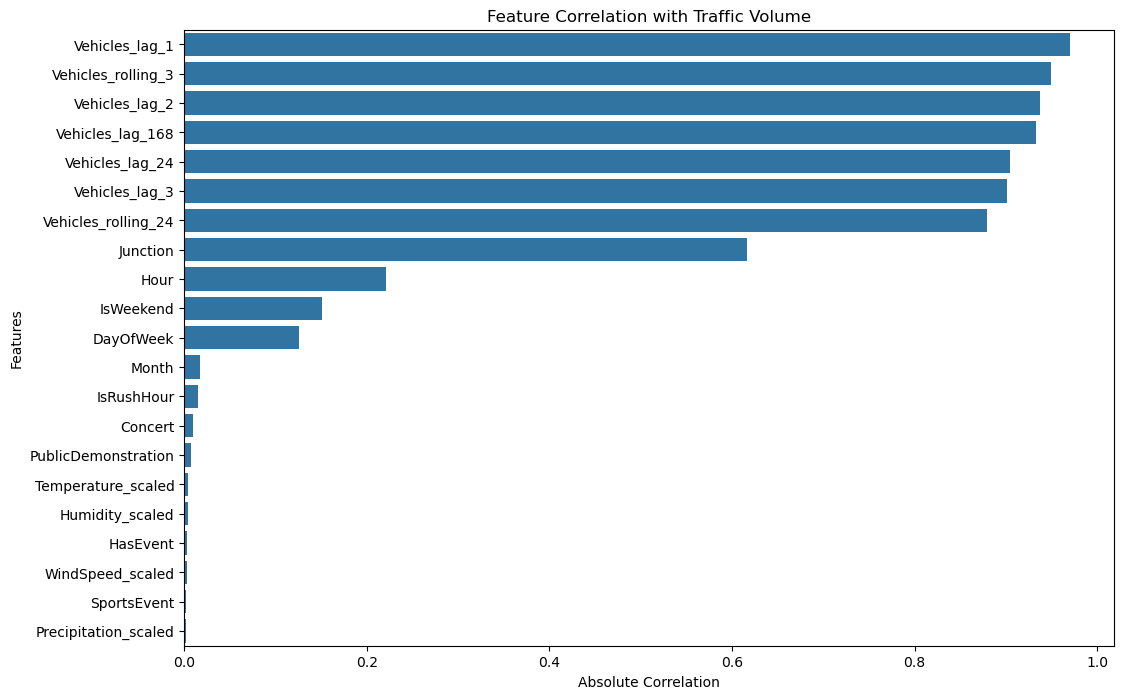

In [129]:
plt.figure(figsize=(12, 8))

sns.barplot(
    x=vehicle_correlation.values,
    y=vehicle_correlation.index
)

plt.title(
    "Feature Correlation with Traffic Volume"
)

plt.xlabel(
    "Absolute Correlation"
)

plt.ylabel(
    "Features"
)

plt.show()

In [130]:
from sklearn.ensemble import RandomForestRegressor

In [131]:
features = [
    "Junction",
    "Hour",
    "DayOfWeek",
    "Month",
    "IsWeekend",
    "IsRushHour",
    "Temperature_scaled",
    "Humidity_scaled",
    "WindSpeed_scaled",
    "Precipitation_scaled",
    "SportsEvent",
    "Concert",
    "PublicDemonstration",
    "HasEvent",
    "Vehicles_lag_1",
    "Vehicles_lag_2",
    "Vehicles_lag_3",
    "Vehicles_lag_24",
    "Vehicles_lag_168",
    "Vehicles_rolling_3",
    "Vehicles_rolling_24"
]

In [133]:
X = df1[features]

y = df1["Vehicles"]

In [134]:
rf_model = RandomForestRegressor(
    n_estimators=100,
    random_state=42,
    n_jobs=-1
)

In [135]:
rf_model.fit(X, y)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""squared_error"", ""absolute_error"", ""friedman_mse"", ""poisson""}, default=""squared_error""The function to measure the quality of a split. Supported criteriaare ""squared_error"" for the mean squared error, which is equal tovariance reduction as feature selection criterion and minimizes the L2loss using the mean of each terminal node, ""friedman_mse"", which usesmean squared error with Friedman's improvement score for potentialsplits, ""absolute_error"" for the mean absolute error, which minimizesthe L1 loss using the median of each terminal node, and ""poisson"" whichuses reduction in Poisson deviance to find splits.Training using ""absolute_error"" is significantly slowerthan when using ""squared_error""... versionadded:: 0.18 Mean Absolute Error (MAE) criterion... versionadded:: 1.0 Poisson criterion.",'squared_error'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=1.0The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None or 1.0, then `max_features=n_features`... note:: The default of 1.0 is equivalent to bagged trees and more randomness can be achieved by setting smaller values, e.g. 0.3... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to 1.0.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",1.0
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsample

In [136]:
feature_importance = pd.DataFrame({
    "Feature": features,
    "Importance": rf_model.feature_importances_
})

In [137]:
feature_importance = (
    feature_importance
    .sort_values(
        by="Importance",
        ascending=False
    )
)

In [138]:
feature_importance

,Feature,Importance
14,Vehicles_lag_1,0.924754
18,Vehicles_lag_168,0.031325
1,Hour,0.006511
20,Vehicles_rolling_24,0.005928
17,Vehicles_lag_24,0.005865
19,Vehicles_rolling_3,0.004081
15,Vehicles_lag_2,0.002830
8,WindSpeed_scaled,0.002792
7,Humidity_scaled,0.002782
6,Temperature_scaled,0.002750


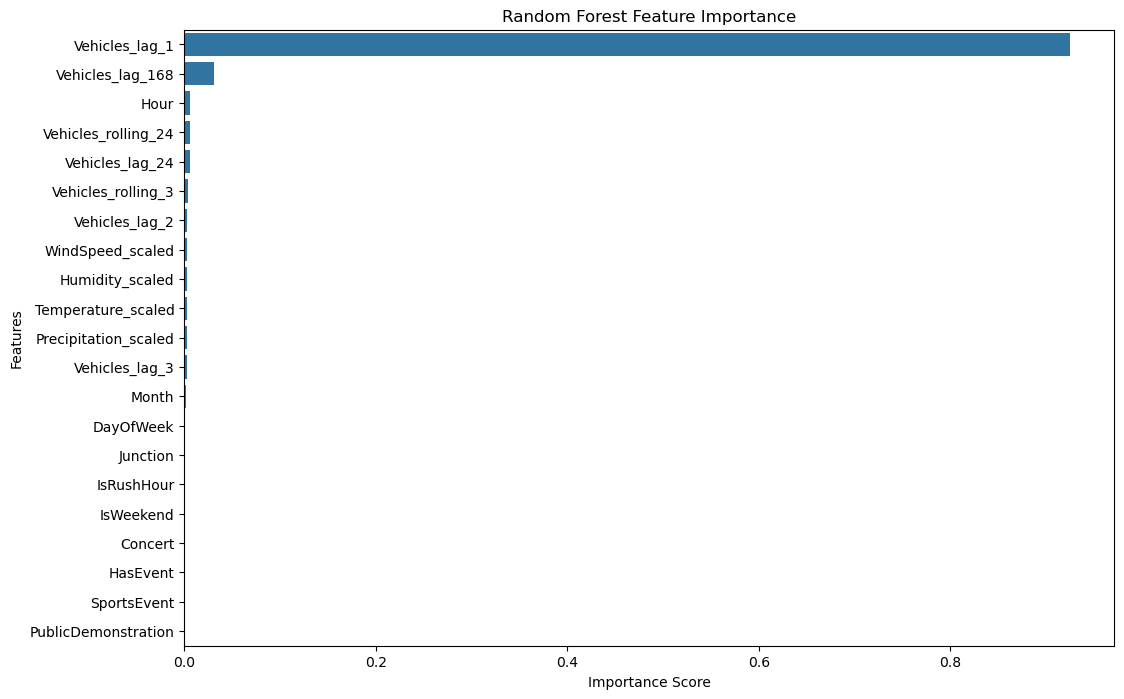

In [139]:
plt.figure(figsize=(12, 8))

sns.barplot(
    data=feature_importance,
    x="Importance",
    y="Feature"
)

plt.title(
    "Random Forest Feature Importance"
)

plt.xlabel(
    "Importance Score"
)

plt.ylabel(
    "Features"
)

plt.show()

In [140]:
feature_importance[
    "Cumulative_Importance"
] = (
    feature_importance["Importance"]
    .cumsum()
)

In [141]:
feature_importance

,Feature,Importance,Cumulative_Importance
14,Vehicles_lag_1,0.924754,0.924754
18,Vehicles_lag_168,0.031325,0.956079
1,Hour,0.006511,0.962590
20,Vehicles_rolling_24,0.005928,0.968518
17,Vehicles_lag_24,0.005865,0.974383
19,Vehicles_rolling_3,0.004081,0.978465
15,Vehicles_lag_2,0.002830,0.981294
8,WindSpeed_scaled,0.002792,0.984087
7,Humidity_scaled,0.002782,0.986868
6,Temperature_scaled,0.002750,0.989619


In [142]:
selected_features = (
    feature_importance[
        feature_importance[
            "Cumulative_Importance"
        ] <= 0.95
    ]["Feature"]
    .tolist()
)

In [143]:
crossing_feature = (
    feature_importance[
        feature_importance[
            "Cumulative_Importance"
        ] > 0.95
    ]
    .head(1)["Feature"]
    .tolist()
)

selected_features += crossing_feature

In [144]:
selected_features = list(
    dict.fromkeys(selected_features)
)

In [145]:
selected_features

['Vehicles_lag_1', 'Vehicles_lag_168']

In [146]:
X_selected = df[
    selected_features
]

y = df1["Vehicles"]

In [147]:
X_selected.head()

,Vehicles_lag_1,Vehicles_lag_168
0,15.0,15.0
1,13.0,13.0
2,16.0,10.0
3,11.0,7.0
4,8.0,9.0


In [148]:
X_selected.shape

(47448, 2)

In [149]:
# df.to_csv(
#     "feature_engineered_traffic_dataset.csv",
#     index=False
# )

In [150]:
selected_df = df[
    selected_features + ["Vehicles"]
]

In [152]:
# selected_df.to_csv(
#     "selected_features_traffic_dataset.csv",
#     index=False
# )